In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib as mpl
from textwrap import fill
from matplotlib.colors import TwoSlopeNorm

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 14 # Axis labels
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick labels
plt.rcParams['font.size'] = 14  # General font size
FONT = 12

code_to_state = {33: 'RJ', 32: 'ES', 41: 'PR', 23: 'CE', 21: 'MA',
 31: 'MG', 42: 'SC', 26: 'PE', 25: 'PB', 24: 'RN', 22: 'PI', 27: 'AL',
 28: 'SE', 35: 'SP', 43: 'RS', 15: 'PA', 16: 'AP', 14: 'RR',  11: 'RO',
 13: 'AM', 12: 'AC', 51: 'MT', 50: 'MS', 52: 'GO', 17: 'TO', 53: 'DF',
 29: 'BA'}

regioes = {
    'Norte': ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste': ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste': ['DF', 'GO', 'MT', 'MS'],
    'Sudeste': ['ES', 'MG', 'RJ', 'SP'],
    'Sul': ['PR', 'RS', 'SC']
}

estado_para_regiao = {est: reg for reg, estados in regioes.items() for est in estados}


In [2]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [3]:
df_agg_wis = (
    df_preds
    .groupby(["model", "adm_1", "validation"], as_index=False)["wis"]
    .mean()
)

# Highest rank = lowest WIS
df_agg_wis["rank"] = (
    df_agg_wis
    .groupby(["adm_1", "validation"])["wis"]
    .rank(method="dense", ascending=False)
)

# Invert so the best model gets the largest rank
max_rank = (
    df_agg_wis
    .groupby(["adm_1", "validation"])["rank"]
    .transform("max")
)

df_agg_wis["rank"] = max_rank - df_agg_wis["rank"] + 1

df_agg_wis.head()

,model,adm_1,validation,wis,rank
0,3rd_imdc_afya_ric,11,1,182.42,22.0
1,3rd_imdc_afya_ric,11,2,99.96,25.0
2,3rd_imdc_afya_ric,11,3,33.80,19.0
3,3rd_imdc_afya_ric,11,4,47.27,18.0
4,3rd_imdc_afya_ric,12,1,56.04,21.0


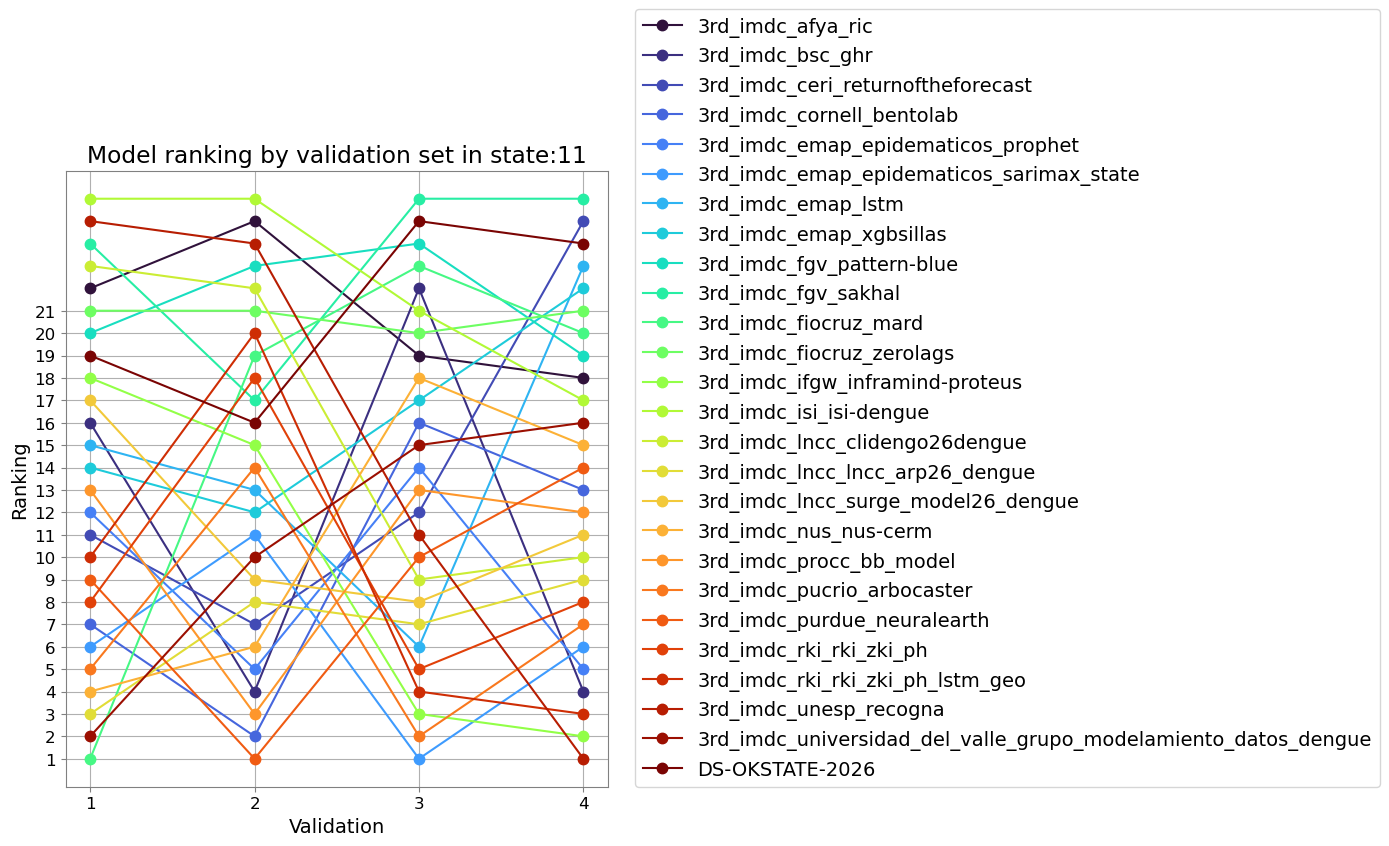

In [ ]:
state = 11
df_ = df_agg_wis.loc[df_agg_wis.adm_1 == state]

models = df_.model.unique()


cmap = plt.colormaps["turbo"]  # ou "viridis", "plasma", "gist_rainbow"

colors = cmap(np.linspace(0, 1, len(models)))
              
_,ax = plt.subplots(figsize = (7, 8))
for i, model in enumerate(models):

    df_to_plot = df_.loc[df_.model == model]
    ax.plot(df_to_plot.validation, df_to_plot['rank'],color = colors[i], label = model, marker = '.', markersize = 15)

    #break 

ax.legend(loc = (1.05,0))

ax.grid()

ax.set_xticks([1,2,3,4])
ax.set_yticks(np.arange(1, 27))

ax.set_xlabel('Validation')
ax.set_ylabel('Ranking')

ax.set_title(f'Model ranking by validation set in state:{state}')

plt.show()

Gerando um ranking pela média dos rankings em cada conjunto: 

In [6]:
# Rank dentro de cada estado e conjunto de validação
df_rank = df_agg_wis.copy()

df_rank["rank"] = (
    df_rank
    .groupby(["adm_1", "validation"])["wis"]
    .rank(method="average", ascending=True)
)

# Rank médio por modelo e estado
df_mean_rank = (
    df_rank
    .groupby(["adm_1", "model"], as_index=False)["rank"]
    .mean()
    .rename(columns={"rank": "mean_rank"})
    .sort_values(["adm_1", "mean_rank"])
)

df_mean_rank['rank'] = df_mean_rank.groupby(['adm_1'])['mean_rank'].rank(method= 'min', ascending = True)

df_mean_rank.head()

,adm_1,model,mean_rank,rank
5,11,3rd_imdc_emap_epidematicos_sarimax_state,6.00,1.0
15,11,3rd_imdc_lncc_lncc_arp26_dengue,6.75,2.0
19,11,3rd_imdc_pucrio_arbocaster,7.00,3.0
20,11,3rd_imdc_purdue_neuralearth,8.50,4.0
4,11,3rd_imdc_emap_epidematicos_prophet,9.00,5.0


In [7]:
df_mean_rank.to_csv('predictions/mean_rk.csv.gz', index = False)

In [8]:
df_rank.loc[(df_rank.adm_1 == 11) & (df_rank.validation == 2)].sort_values(by = 'rank')

,model,adm_1,validation,wis,rank
2108,3rd_imdc_purdue_neuralearth,11,2,26.285783,1.0
313,3rd_imdc_cornell_bentolab,11,2,29.720000,2.0
1897,3rd_imdc_procc_bb_model,11,2,31.277812,3.0
105,3rd_imdc_bsc_ghr,11,2,32.576178,4.0
421,3rd_imdc_emap_epidematicos_prophet,11,2,33.011145,5.0
1793,3rd_imdc_nus_nus-cerm,11,2,33.585101,6.0
209,3rd_imdc_ceri_returnoftheforecast,11,2,34.190000,7.0
1577,3rd_imdc_lncc_lncc_arp26_dengue,11,2,35.006517,8.0
1685,3rd_imdc_lncc_surge_model26_dengue,11,2,36.170464,9.0
2528,3rd_imdc_universidad_del_valle_grupo_modelamie...,11,2,36.915418,10.0


In [9]:
df_rank.loc[(df_rank.model == '3rd_imdc_fiocruz_mard') & (df_rank.adm_1 == 11)]

,model,adm_1,validation,wis,rank
1048,3rd_imdc_fiocruz_mard,11,1,68.696713,1.0
1049,3rd_imdc_fiocruz_mard,11,2,63.551341,19.0
1050,3rd_imdc_fiocruz_mard,11,3,56.420000,23.0
1051,3rd_imdc_fiocruz_mard,11,4,51.070000,20.0


Gerando um ranking da média da diferença entre os modelos e o baseline: 

In [5]:
model_baseline = '3rd_imdc_procc_bb_model'

df_baseline = (
    df_agg_wis.loc[df_agg_wis["model"] == model_baseline,
           ["adm_1", "validation", "wis"]]
    .rename(columns={"wis": "wis_baseline"})
)

# Junta o WIS do baseline aos demais modelos
df_ratio = df_agg_wis.merge(
    df_baseline,
    on=["adm_1", "validation"],
    how="left"
)

# Razão WIS / Baseline
df_ratio["wis_ratio"] = (
    df_ratio["wis"] / df_ratio["wis_baseline"]
)

# Médias das razões
df_summary = (
    df_ratio
    .groupby(["adm_1", "model"], as_index=False)
    .agg(
        arithmetic_mean_ratio=("wis_ratio", "mean"),
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_1", "geometric_mean_ratio"])
)

df_summary.head()

,adm_1,model,arithmetic_mean_ratio,geometric_mean_ratio
5,11,3rd_imdc_emap_epidematicos_sarimax_state,0.803841,0.769598
19,11,3rd_imdc_pucrio_arbocaster,0.834013,0.789304
15,11,3rd_imdc_lncc_lncc_arp26_dengue,0.818201,0.800598
12,11,3rd_imdc_ifgw_inframind-proteus,0.964784,0.845450
22,11,3rd_imdc_rki_rki_zki_ph_lstm_geo,1.087766,0.900748


In [6]:
df_ratio['region'] = df_ratio['adm_1'].replace(code_to_state).replace(estado_para_regiao)

df_ratio.to_csv('predictions/rank_ratio.csv.gz', index = False)

In [11]:
df_summary.loc[df_summary.adm_1 == 11].sort_values(by = 'arithmetic_mean_ratio')

,adm_1,model,arithmetic_mean_ratio,geometric_mean_ratio
5,11,3rd_imdc_emap_epidematicos_sarimax_state,0.803841,0.769598
15,11,3rd_imdc_lncc_lncc_arp26_dengue,0.818201,0.800598
19,11,3rd_imdc_pucrio_arbocaster,0.834013,0.789304
20,11,3rd_imdc_purdue_neuralearth,0.919903,0.908826
4,11,3rd_imdc_emap_epidematicos_prophet,0.926811,0.915728
12,11,3rd_imdc_ifgw_inframind-proteus,0.964784,0.845450
3,11,3rd_imdc_cornell_bentolab,0.969922,0.959128
18,11,3rd_imdc_procc_bb_model,1.000000,1.000000
21,11,3rd_imdc_rki_rki_zki_ph,1.001139,0.931077
17,11,3rd_imdc_nus_nus-cerm,1.018150,0.995520


In [12]:
df_mean_rank.loc[df_mean_rank.adm_1 == 11]

,adm_1,model,mean_rank,rank
5,11,3rd_imdc_emap_epidematicos_sarimax_state,6.00,1.0
15,11,3rd_imdc_lncc_lncc_arp26_dengue,6.75,2.0
19,11,3rd_imdc_pucrio_arbocaster,7.00,3.0
20,11,3rd_imdc_purdue_neuralearth,8.50,4.0
4,11,3rd_imdc_emap_epidematicos_prophet,9.00,5.0
22,11,3rd_imdc_rki_rki_zki_ph_lstm_geo,9.25,6.0
3,11,3rd_imdc_cornell_bentolab,9.50,7.0
12,11,3rd_imdc_ifgw_inframind-proteus,9.50,7.0
21,11,3rd_imdc_rki_rki_zki_ph,9.75,9.0
18,11,3rd_imdc_procc_bb_model,10.25,10.0


In [13]:
df_summary.loc[df_summary.adm_1 == 11].sort_values(by = 'geometric_mean_ratio')

,adm_1,model,arithmetic_mean_ratio,geometric_mean_ratio
5,11,3rd_imdc_emap_epidematicos_sarimax_state,0.803841,0.769598
19,11,3rd_imdc_pucrio_arbocaster,0.834013,0.789304
15,11,3rd_imdc_lncc_lncc_arp26_dengue,0.818201,0.800598
12,11,3rd_imdc_ifgw_inframind-proteus,0.964784,0.845450
22,11,3rd_imdc_rki_rki_zki_ph_lstm_geo,1.087766,0.900748
20,11,3rd_imdc_purdue_neuralearth,0.919903,0.908826
4,11,3rd_imdc_emap_epidematicos_prophet,0.926811,0.915728
21,11,3rd_imdc_rki_rki_zki_ph,1.001139,0.931077
3,11,3rd_imdc_cornell_bentolab,0.969922,0.959128
17,11,3rd_imdc_nus_nus-cerm,1.018150,0.995520


Usar a média aritmética ou geométrica muda um pouco o ranking

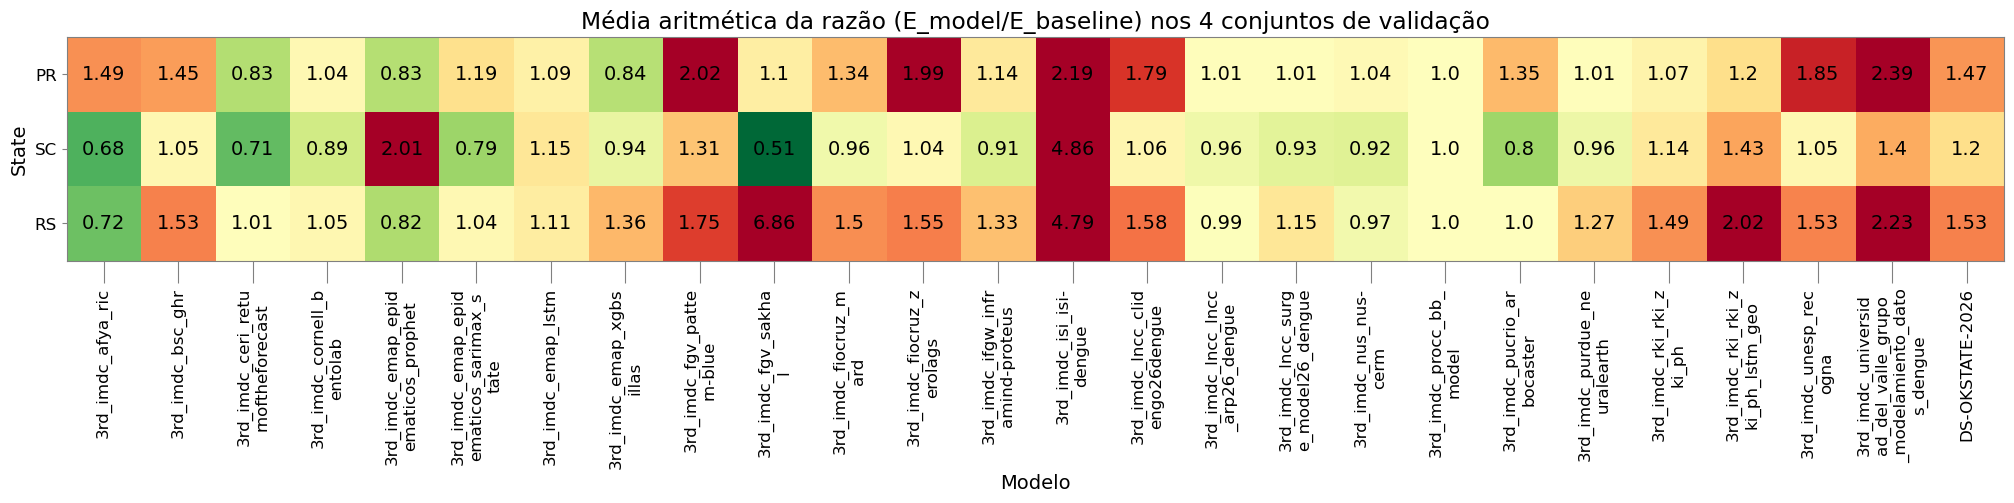

In [14]:
df_summary['state'] = df_summary.adm_1.replace(code_to_state)

df_sum_pivot = df_summary.loc[df_summary.adm_1 != 32].pivot(index = 'state', columns = 'model', values = 'arithmetic_mean_ratio')

df_sum_pivot = df_sum_pivot.loc[['PR', 'SC', 'RS']]

norm = TwoSlopeNorm(
    vmin=df_sum_pivot.values.min(),
    vcenter=1,
    vmax=2)

fig, ax = plt.subplots(figsize = (25, 5))

# Show as image
im = ax.imshow(df_sum_pivot.values,cmap="RdYlGn_r",
    norm=norm)

# Add labels
ax.set_xticks(np.arange(df_sum_pivot.shape[1]))
ax.set_yticks(np.arange(df_sum_pivot.shape[0]))
ax.set_xticklabels(df_sum_pivot.columns)
ax.set_yticklabels(df_sum_pivot.index)

for i in range(df_sum_pivot.shape[0]):
    for j in range(df_sum_pivot.shape[1]):
        text = ax.text(j, i, round(df_sum_pivot.iloc[i, j], 2),
                       ha="center", va="center", color="black")


labels = [fill(label.get_text(), width=18)
          for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)

     
ax.set_xlabel('Modelo')
ax.tick_params(axis="x", rotation=90, size =16)
ax.set_ylabel('State')
ax.set_title('Média aritmética da razão (E_model/E_baseline) nos 4 conjuntos de validação')
plt.show()

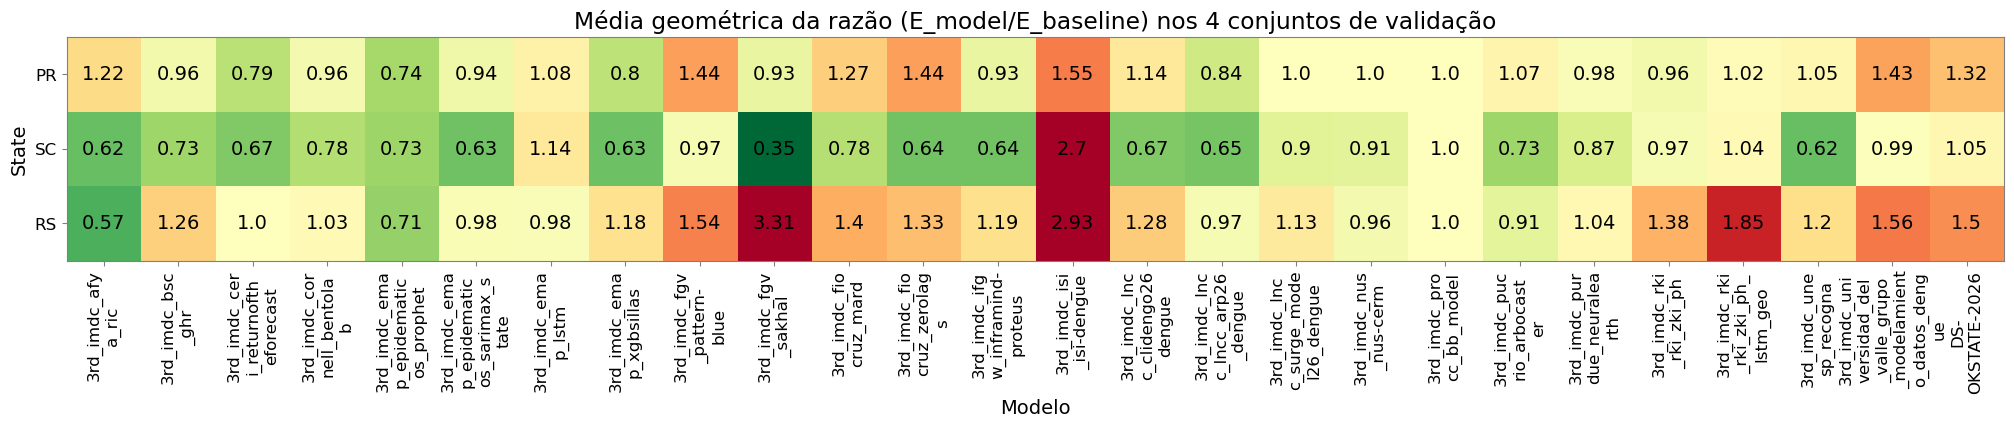

In [15]:
df_summary['state'] = df_summary.adm_1.replace(code_to_state)

df_sum_pivot = df_summary.loc[df_summary.adm_1 != 32].pivot(index = 'state', columns = 'model', values = 'geometric_mean_ratio')

df_sum_pivot = df_sum_pivot.loc[['PR', 'SC', 'RS']]

norm = TwoSlopeNorm(
    vmin=df_sum_pivot.values.min(),
    vcenter=1,
    vmax=2)

fig, ax = plt.subplots(figsize = (25, 5))

# Show as image
im = ax.imshow(df_sum_pivot.values,cmap="RdYlGn_r",
    norm=norm)

# Add labels
ax.set_xticks(np.arange(df_sum_pivot.shape[1]))
ax.set_yticks(np.arange(df_sum_pivot.shape[0]))
ax.set_xticklabels(df_sum_pivot.columns)
ax.set_yticklabels(df_sum_pivot.index)

for i in range(df_sum_pivot.shape[0]):
    for j in range(df_sum_pivot.shape[1]):
        text = ax.text(j, i, round(df_sum_pivot.iloc[i, j], 2),
                       ha="center", va="center", color="black")


labels = [fill(label.get_text(), width=12)
          for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)

     
ax.set_xlabel('Modelo')
ax.tick_params(axis="x", rotation=90)
ax.set_ylabel('State')
ax.set_title('Média geométrica da razão (E_model/E_baseline) nos 4 conjuntos de validação')
plt.show()

In [ ]:
column = 'geometric_mean_ratio'

df_ = df_summary[['adm_1', 'model', column]].copy()

df_["rank"] = (
    df_.groupby(["adm_1"])[[column]].rank(method="min", ascending=True)
)

df_.to_csv('predictions/mg_base_rk_geral.csv.gz', index = False)

In [29]:
df_ratio['region'] = df_ratio['adm_1'].replace(code_to_state).replace(estado_para_regiao)

df_best_region_model = df_ratio.groupby(["region", "model"], as_index=False).agg(
        arithmetic_mean_ratio=("wis_ratio", "mean"),
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    ).sort_values(["region", "geometric_mean_ratio"]) 


df_best_region_model["rank"] = (
    df_best_region_model.groupby(["region"])[[column]].rank(method="min", ascending=True)
)

df_best_region_model.head()

,region,model,arithmetic_mean_ratio,geometric_mean_ratio,rank
5,Centro-Oeste,3rd_imdc_emap_epidematicos_sarimax_state,0.891826,0.804123,1.0
12,Centro-Oeste,3rd_imdc_ifgw_inframind-proteus,0.996070,0.838807,2.0
20,Centro-Oeste,3rd_imdc_purdue_neuralearth,0.939682,0.894167,3.0
19,Centro-Oeste,3rd_imdc_pucrio_arbocaster,1.178763,0.947244,4.0
4,Centro-Oeste,3rd_imdc_emap_epidematicos_prophet,1.083081,0.964132,5.0


Fazer o medal board: 

In [ ]:
df_

(26,)